# SpatialEval - VLM Spatial Reasoning Analysis

This notebook provides a comprehensive analysis of **11 Vision-Language Models** evaluated on the **SpatialEval benchmark** (NeurIPS 2024).

**Benchmark**: 4,635 samples per model across 4 spatial reasoning tasks in VQA mode (with chain-of-thought reasoning).

**Models**: Molmo2-4B/8B, Qwen3-VL-4B/8B, InternVL3-4B/8B, LLaVA-OV-1.5-4B/8B, MiniCPM-V-4.5, SAIL-VL2-8B, Gemma-3-4b

**Sections**:
1. Results Overview - Overall and per-task accuracy rankings
2. Per-Question-Type Breakdown - Fine-grained accuracy by question type within each task
3. Answer Extraction Robustness - Comparing 4 evaluation strategies (substring vs exact vs word-boundary vs option-letter)
4. Error Analysis with Sample Images - Visualizing model errors on original benchmark images
5. Per-Instance Difficulty - Identifying the hardest and easiest questions
6. Model Correlation - How similar are model correctness patterns?
7. Confusion Analysis - Which directions/animals do models confuse?
8. Answer Format Analysis - How do models format their responses?

## Setup & Data Loading

Load all 11 model outputs (50,985 total predictions) and apply 4 evaluation strategies during data loading.

In [1]:
import json, os, re, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from IPython.display import display, HTML

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

sys.path.insert(0, '.')
from evals.evaluation import (
    extract_answer_from_text_spatialmap,
    extract_answer_from_text_mazenav,
    extract_answer_from_text_spatialgrid,
    extract_answer_from_text_spatialreal,
)
from evals.eval_robust import (
    extract_option_letter, match_substring, match_exact,
    match_word_boundary, match_option_letter, MODEL_SHORT,
    TASK_QID_LABELS, DATA_DIR, EXTRACTORS,
)

# Short names and ordered model list
MODEL_ORDER = [
    'Molmo2-8B', 'Qwen3-4B', 'MiniCPM-V-4.5', 'Molmo2-4B',
    'SAIL-VL2-8B', 'Qwen3-8B', 'LLaVA-OV-4B', 'InternVL3-4B',
    'InternVL3-8B', 'LLaVA-OV-8B', 'Gemma3-4B'
]

FAMILY_COLORS = {
    'Molmo2': '#2ecc71', 'Qwen3': '#3498db', 'MiniCPM': '#9b59b6',
    'SAIL': '#1abc9c', 'LLaVA': '#e74c3c', 'InternVL': '#e67e22',
    'Gemma': '#e91e63',
}

def family_of(name):
    for k in FAMILY_COLORS:
        if k in name:
            return k
    return 'Other'

MODEL_PALETTE = {m: FAMILY_COLORS[family_of(m)] for m in MODEL_ORDER}

In [2]:
# Load all data
DATA_DIR_PATH = DATA_DIR
records = []

for filename in sorted(os.listdir(DATA_DIR_PATH)):
    if not filename.endswith('.jsonl'):
        continue
    model_name = filename.replace('m-', '').replace('_w_reason.jsonl', '')
    short = MODEL_SHORT.get(model_name, model_name)
    with open(os.path.join(DATA_DIR_PATH, filename)) as fh:
        for line in fh:
            item = json.loads(line)
            sid = item['id']
            parts = sid.split('.')
            task, qid = parts[0], int(parts[-1])
            raw = item.get('answer', '')
            oracle = item.get('oracle_answer', '')
            opt = item.get('oracle_option', '')

            ext_fn = EXTRACTORS.get(task)
            try:
                extracted = ext_fn(raw, qid, model_name) if ext_fn else None
            except Exception:
                extracted = None

            ext_str = str(extracted).lower().strip() if extracted is not None else ''
            oracle_str = str(oracle).lower().strip() if oracle else ''

            records.append({
                'model': short, 'sample_id': sid, 'task': task, 'qid': qid,
                'task_qid': TASK_QID_LABELS.get((task, qid), f'{task}:q{qid}'),
                'oracle': oracle_str, 'oracle_option': (opt or '').upper(),
                'extracted': ext_str,
                'raw': raw[:500] if raw else '',
                'substring': match_substring(oracle_str, ext_str),
                'exact': match_exact(oracle_str, ext_str),
                'word_boundary': match_word_boundary(oracle or '', ext_str),
                'option_letter': match_option_letter(raw, opt or ''),
            })

df = pd.DataFrame(records)
print(f'Loaded {len(df)} samples, {df["model"].nunique()} models')
df.head()

Loaded 50985 samples, 11 models


,model,sample_id,task,qid,task_qid,oracle,oracle_option,extracted,raw,substring,exact,word_boundary,option_letter
0,SAIL-VL2-8B,spatialmap.vqa.2000.0,spatialmap,0,Map: Direction,northeast,A,northeast,A. Northeast.\n\nStep-by-step explanation:\n1....,True,True,True,True
1,SAIL-VL2-8B,spatialmap.vqa.2001.0,spatialmap,0,Map: Direction,southeast,C,southeast,C. Southeast\n\nTo determine the direction of ...,True,True,True,True
2,SAIL-VL2-8B,spatialmap.vqa.2002.0,spatialmap,0,Map: Direction,northeast,B,northeast,B. Northeast.\n\nStep-by-step explanation:\n1....,True,True,True,True
3,SAIL-VL2-8B,spatialmap.vqa.2003.0,spatialmap,0,Map: Direction,northeast,C,northeast,C. Northeast.\n\nTo determine the direction of...,True,True,True,True
4,SAIL-VL2-8B,spatialmap.vqa.2004.0,spatialmap,0,Map: Direction,northwest,C,northwest,C. Northwest.\n\nTo determine the direction of...,True,True,True,True


## 1. Results Overview

**Purpose**: Establish the overall ranking of all 11 models and identify which spatial tasks are easier or harder.

- **Figure 1a** shows a horizontal bar chart of overall accuracy (exact match) across all 4,635 samples, sorted from best to worst.
- **Figure 1b** is a heatmap showing accuracy broken down by model (rows) and task (columns), revealing task-specific strengths and weaknesses.

**Key questions answered**:
- Which model is the best overall at spatial reasoning?
- Are there tasks where a lower-ranked model outperforms the leader?
- How large is the gap between the best and worst model?

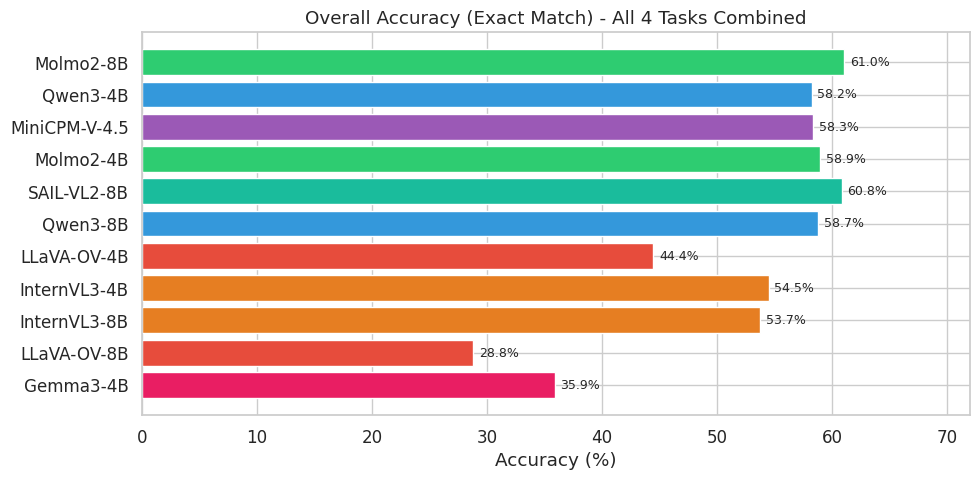

In [3]:
# 1a: Overall accuracy bar chart
overall = df.groupby('model')['exact'].mean().reindex(MODEL_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [MODEL_PALETTE.get(m, '#999') for m in overall.index]
bars = ax.barh(range(len(overall)), overall.values * 100, color=colors)
ax.set_yticks(range(len(overall)))
ax.set_yticklabels(overall.index)
ax.invert_yaxis()
ax.set_xlabel('Accuracy (%)')
ax.set_title('Overall Accuracy (Exact Match) - All 4 Tasks Combined')
for i, v in enumerate(overall.values):
    ax.text(v * 100 + 0.5, i, f'{v*100:.1f}%', va='center', fontsize=9)
ax.set_xlim(0, 72)
plt.tight_layout()
plt.savefig('analysis_figures/01_overall_accuracy.png', dpi=150)
plt.show()

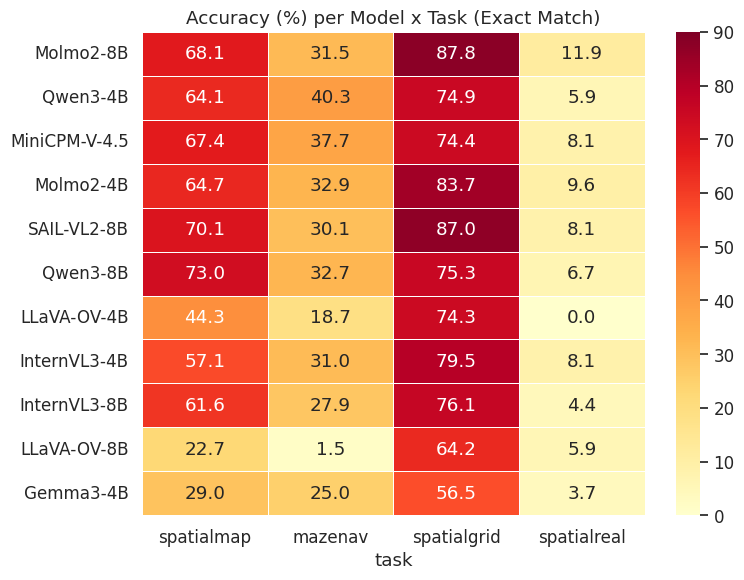

In [4]:
# 1b: Heatmap - accuracy per model x task
pivot = df.groupby(['model', 'task'])['exact'].mean().unstack()
pivot = pivot.reindex(MODEL_ORDER)[['spatialmap', 'mazenav', 'spatialgrid', 'spatialreal']]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot * 100, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, vmin=0, vmax=90, linewidths=0.5)
ax.set_ylabel('')
ax.set_title('Accuracy (%) per Model x Task (Exact Match)')
plt.tight_layout()
plt.savefig('analysis_figures/02_heatmap_task.png', dpi=150)
plt.show()

## 2. Per-Question-Type Breakdown

**Purpose**: Each SpatialEval task contains multiple question types (identified by `qid`). This section breaks down accuracy at the finest granularity to reveal which specific reasoning abilities are strong or weak for each model.

- **Figure 2a** shows 4 grouped bar charts (one per task), with bars grouped by question ID. This reveals, for example, whether a model that excels at counting paths (mazenav qid0) also excels at determining reachability (mazenav qid2).
- **Table 2b** presents the full accuracy matrix with the best model per question type highlighted.

| Task | qid 0 | qid 1 | qid 2 |
|------|-------|-------|-------|
| spatialmap | Direction | Nearest Object | Count |
| mazenav | Right Turns | Total Turns | Yes/No |
| spatialgrid | Count | Animal ID | Animal at Position |
| spatialreal | Mixed | - | - |

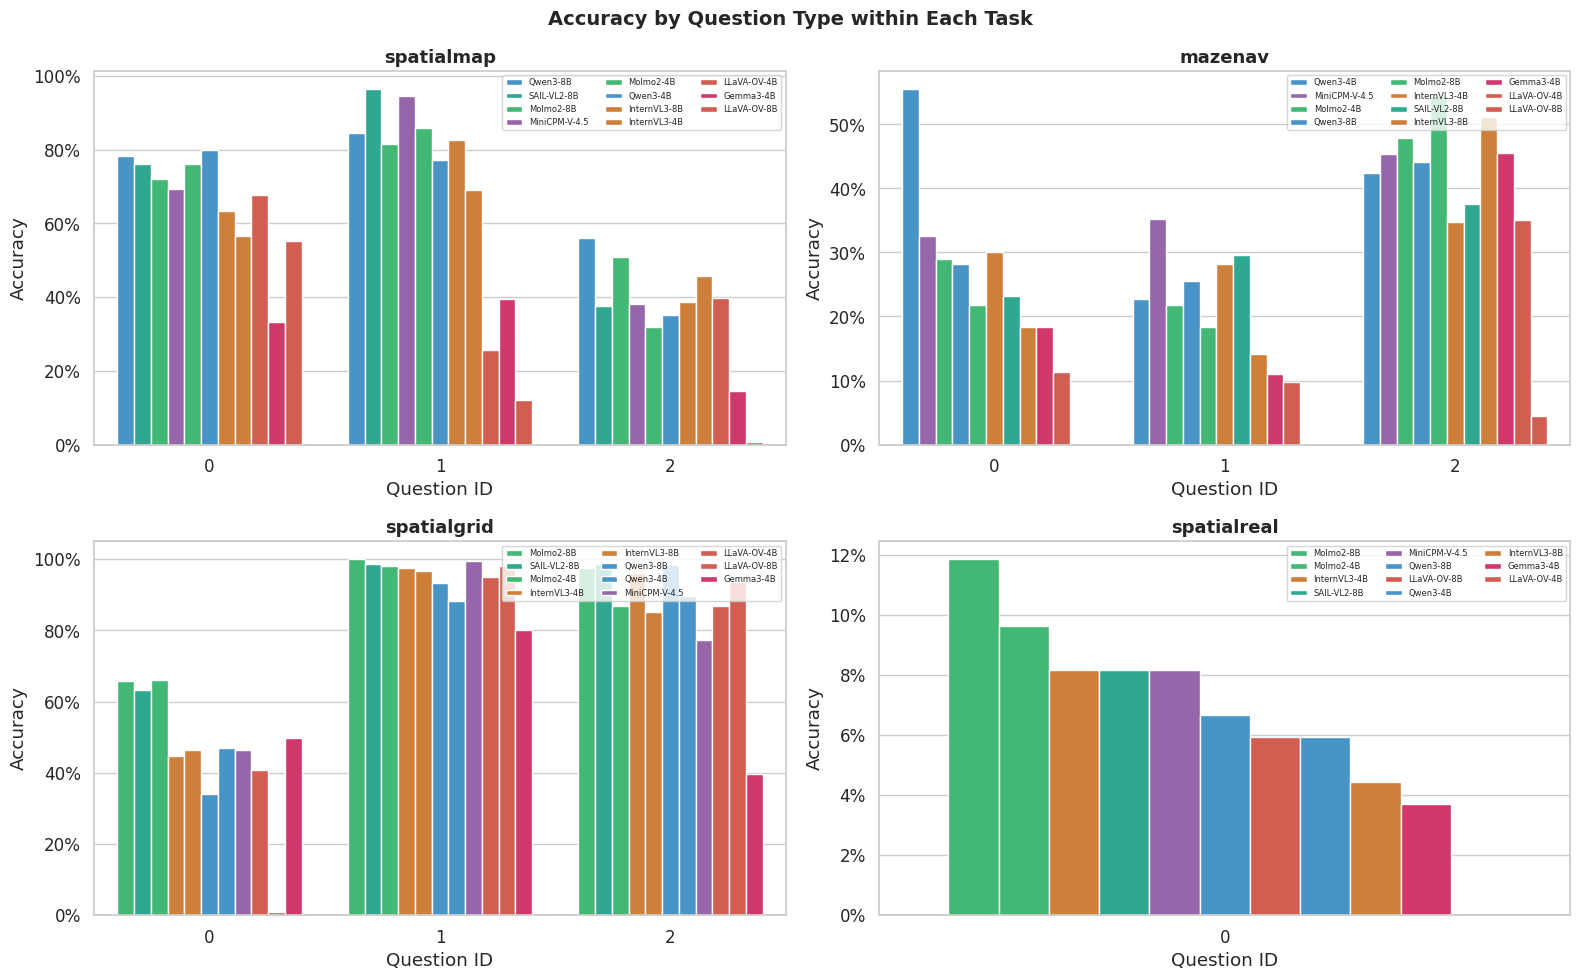

In [5]:
# 2a: Grouped bar charts per task
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
tasks = ['spatialmap', 'mazenav', 'spatialgrid', 'spatialreal']

for ax, task in zip(axes.flat, tasks):
    tdf = df[df['task'] == task]
    acc = tdf.groupby(['model', 'qid'])['exact'].mean().reset_index()
    acc['qid_label'] = acc['qid'].astype(str)
    model_order_t = acc.groupby('model')['exact'].mean().sort_values(ascending=False).index.tolist()
    acc['model'] = pd.Categorical(acc['model'], categories=model_order_t, ordered=True)

    sns.barplot(data=acc, x='qid_label', y='exact', hue='model',
                palette=MODEL_PALETTE, ax=ax, hue_order=model_order_t)
    ax.set_title(f'{task}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Question ID')
    ax.set_ylabel('Accuracy')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.legend(fontsize=6, ncol=3, loc='upper right')

plt.suptitle('Accuracy by Question Type within Each Task', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('analysis_figures/03_per_question_type.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# 2b: Detailed accuracy table
acc_detail = df.groupby(['model', 'task_qid'])['exact'].mean().unstack()
acc_detail = acc_detail.reindex(MODEL_ORDER)
cols_ordered = [TASK_QID_LABELS.get((t, q), '') for t in ['spatialmap','mazenav','spatialgrid','spatialreal'] for q in range(3)]
cols_present = [c for c in cols_ordered if c in acc_detail.columns]
acc_detail = acc_detail[cols_present]
acc_detail.style.format('{:.1%}').highlight_max(axis=0, color='lightgreen')

task_qid,Map: Direction,Map: Object,Map: Count,Maze: Right Turns,Maze: Total Turns,Maze: Yes/No,Grid: Count,Grid: Animal ID,Grid: Animal Pos,Real: Mixed
model,,,,,,,,,,
Molmo2-8B,72.0%,81.6%,50.8%,21.8%,18.4%,54.4%,65.8%,100.0%,97.6%,11.9%
Qwen3-4B,80.0%,77.2%,35.2%,55.6%,22.8%,42.4%,47.0%,88.2%,89.6%,5.9%
MiniCPM-V-4.5,69.4%,94.6%,38.2%,32.6%,35.2%,45.4%,46.4%,99.4%,77.4%,8.1%
Molmo2-4B,76.2%,85.8%,32.0%,29.0%,21.8%,47.8%,66.0%,98.0%,87.0%,9.6%
SAIL-VL2-8B,76.0%,96.6%,37.6%,23.2%,29.6%,37.6%,63.4%,98.8%,98.8%,8.1%
Qwen3-8B,78.4%,84.6%,56.0%,28.2%,25.6%,44.2%,34.0%,93.4%,98.4%,6.7%
LLaVA-OV-4B,67.6%,25.6%,39.8%,11.4%,9.8%,35.0%,40.8%,95.0%,87.0%,0.0%
InternVL3-4B,56.6%,69.0%,45.6%,30.0%,28.2%,34.8%,44.6%,97.6%,96.2%,8.1%
InternVL3-8B,63.4%,82.6%,38.8%,18.4%,14.2%,51.2%,46.4%,96.6%,85.2%,4.4%


## 3. Answer Extraction Robustness

**Purpose**: The original SpatialEval evaluation uses **substring matching** (`oracle_answer in model_answer`), which can produce false positives. For example, oracle `"six"` matches model answer `"sixteen"`, and oracle `"2"` matches `"12"`. This section compares 4 evaluation strategies to quantify how much substring matching inflates scores.

**Strategies compared**:
| Strategy | Logic | Potential Issue |
|----------|-------|----------------|
| **substring** | `oracle in extracted` | False positives: "six" in "sixteen" |
| **exact** | `oracle == extracted` | Strict, no tolerance for formatting |
| **word_boundary** | regex `\boracle\b` in extracted | Prevents partial word matching |
| **option_letter** | Extract A/B/C/D from raw answer | Bypasses text extraction entirely |

- **Figure 3a** compares all 4 strategies side-by-side for each model.
- **Figure 3b** shows the inflation delta (substring - exact) per task, highlighting where substring matching inflates scores the most.
- **Table 3c** enumerates the false positives with concrete examples.

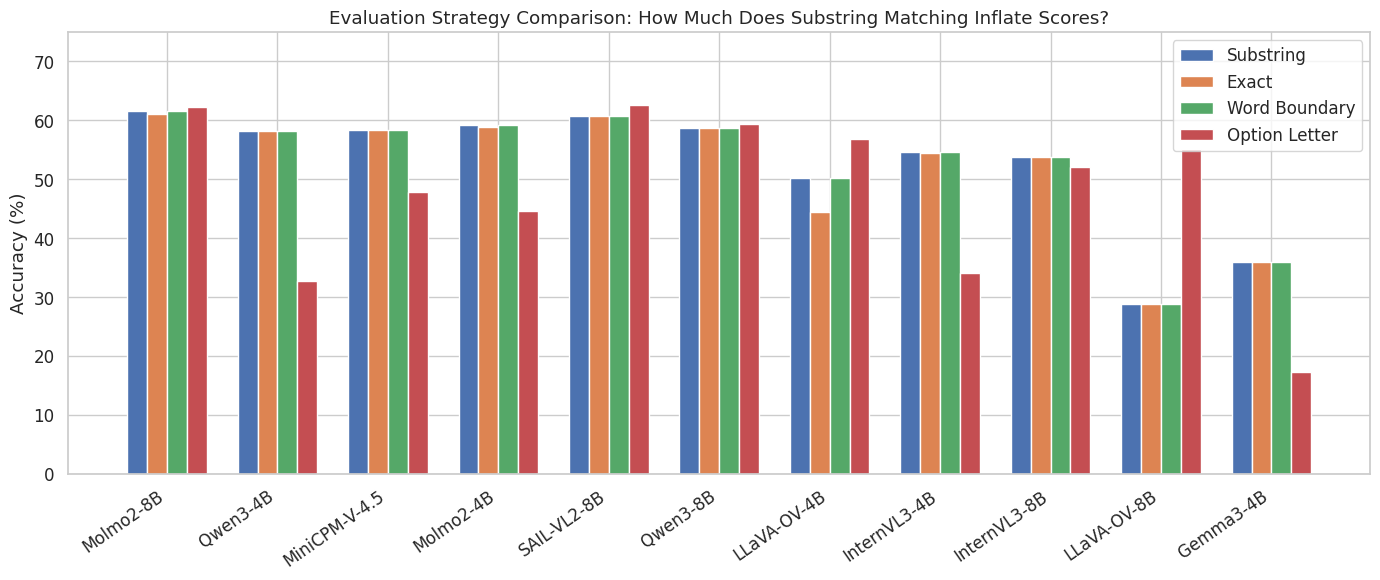

In [7]:
# 3a: Side-by-side strategy comparison
strategies = ['substring', 'exact', 'word_boundary', 'option_letter']
strat_acc = df.groupby('model')[strategies].mean().reindex(MODEL_ORDER) * 100

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(MODEL_ORDER))
width = 0.18
for i, s in enumerate(strategies):
    ax.bar(x + i * width, strat_acc[s], width, label=s.replace('_', ' ').title())
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(MODEL_ORDER, rotation=35, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Evaluation Strategy Comparison: How Much Does Substring Matching Inflate Scores?')
ax.legend()
ax.set_ylim(0, 75)
plt.tight_layout()
plt.savefig('analysis_figures/04_strategy_comparison.png', dpi=150)
plt.show()

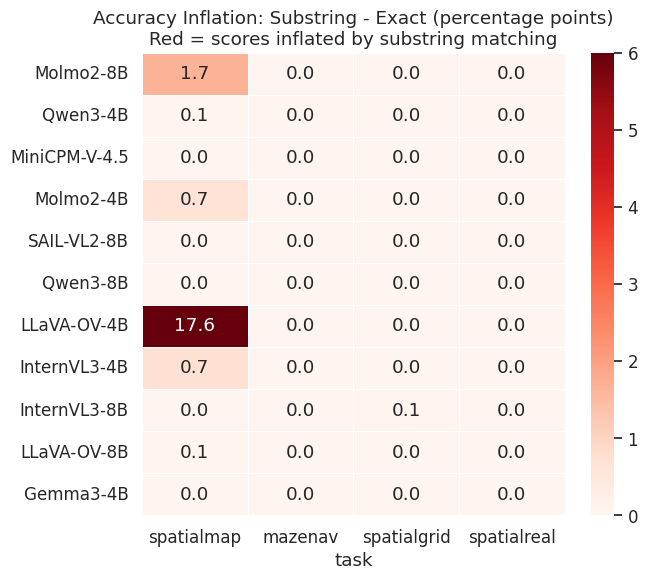

In [8]:
# 3b: Delta heatmap (substring - exact)
delta = df.groupby(['model', 'task']).agg(
    sub=('substring', 'mean'), exc=('exact', 'mean')
).reset_index()
delta['diff'] = delta['sub'] - delta['exc']
delta_pivot = delta.pivot(index='model', columns='task', values='diff')
delta_pivot = delta_pivot.reindex(MODEL_ORDER)[['spatialmap','mazenav','spatialgrid','spatialreal']]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(delta_pivot * 100, annot=True, fmt='.1f', cmap='Reds',
            ax=ax, linewidths=0.5, vmin=0, vmax=6)
ax.set_ylabel('')
ax.set_title('Accuracy Inflation: Substring - Exact (percentage points)\nRed = scores inflated by substring matching')
plt.tight_layout()
plt.savefig('analysis_figures/05_delta_heatmap.png', dpi=150)
plt.show()

In [9]:
# 3c: Disagreement summary
fp = df[df['substring'] & ~df['exact']].copy()
fn = df[~df['substring'] & df['exact']].copy()

print(f'False Positives (substring correct, exact wrong): {len(fp)}')
print(f'False Negatives (substring wrong, exact correct): {len(fn)}')
print()
print('FP breakdown by (model, task):')
if len(fp) > 0:
    for (m, t), grp in fp.groupby(['model', 'task']):
        print(f'  {m:<18} {t:<15} {len(grp)} FP')
        sample = grp.iloc[0]
        print(f'    Example: oracle="{sample["oracle"]}" | extracted="{sample["extracted"][:80]}"')
        print()

False Positives (substring correct, exact wrong): 313
False Negatives (substring wrong, exact correct): 0

FP breakdown by (model, task):
  InternVL3-4B       spatialmap      11 FP
    Example: oracle="frost funhouse" | extracted=""frost funhouse"

  InternVL3-8B       spatialgrid     1 FP
    Example: oracle="5" | extracted="25"

  LLaVA-OV-4B        spatialmap      264 FP
    Example: oracle="narwhal's novelties" | extracted="narwhal's novelties the reasoning involves identifying the relative positions of"

  LLaVA-OV-8B        spatialmap      1 FP
    Example: oracle="nebula newsstand" | extracted="the object 'nebula newsstand'"

  Molmo2-4B          spatialmap      10 FP
    Example: oracle="fresh foods" | extracted="fresh foods to determine this, we need to analyze the positions of all objects r"

  Molmo2-8B          spatialmap      25 FP
    Example: oracle="art supplies" | extracted="art supplies explanation: to determine the southwest object, we need to identify"

  Qwen3-4B  

## 4. Error Analysis with Sample Images

**Purpose**: Go beyond accuracy numbers and visually inspect **why** models fail. For each task, we select representative error cases and display:
1. The **original benchmark image** (the actual input to the model)
2. The **question text** (what the model was asked)
3. The **ground truth answer** and the **model's prediction**
4. The **model's reasoning** (chain-of-thought)

This qualitative analysis reveals systematic error patterns:
- **spatialmap**: Direction confusion (e.g., northeast vs southeast) when objects are close to axis boundaries
- **mazenav**: Path counting errors due to complex intersections
- **spatialgrid**: Animal misidentification or off-by-one counting errors
- **spatialreal**: Counting failures on cluttered real-world images

In [10]:
# Load dataset for image access
from datasets import load_dataset
import os
os.environ['HF_DATASETS_OFFLINE'] = '1'

ds = load_dataset('MilaWang/SpatialEval', 'vqa', split='test', 
                  cache_dir='/root/autodl-fs/datasets')

# Build id -> index lookup for fast access
id_to_idx = {item['id']: i for i, item in enumerate(ds)}
print(f'Dataset loaded: {len(ds)} samples')
print(f'ID lookup built: {len(id_to_idx)} entries')

Dataset loaded: 4635 samples
ID lookup built: 4635 entries


In [11]:
def show_error_case(sample_id, model_name=None):
    """Display an error case with original image, question, GT, and model prediction."""
    idx = id_to_idx.get(sample_id)
    if idx is None:
        print(f'Sample {sample_id} not found in dataset')
        return
    
    sample = ds[idx]
    img = sample['image']
    question = sample['text']
    oracle = sample['oracle_answer']
    oracle_opt = sample['oracle_option']
    
    # Get model predictions
    preds = df[df['sample_id'] == sample_id].copy()
    if model_name:
        preds = preds[preds['model'] == model_name]
    
    parts = sample_id.split('.')
    task, qid = parts[0], int(parts[-1])
    
    # Display image
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(img)
    ax.set_title(f'{task} (qid={qid})', fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Display info
    print(f'ID: {sample_id}')
    print(f'Task: {task} | Question type: qid={qid}')
    print(f'Ground Truth: {oracle} (Option {oracle_opt})')
    print(f'Question: {question[:400]}...')
    print()
    
    # Show predictions from top models
    display_models = model_name if model_name else ['Molmo2-8B', 'Qwen3-4B', 'MiniCPM-V-4.5', 'LLaVA-OV-8B']
    if isinstance(display_models, str):
        display_models = [display_models]
    
    for m in display_models:
        mp = preds[preds['model'] == m]
        if len(mp) == 0:
            continue
        row = mp.iloc[0]
        status = 'CORRECT' if row['exact'] else 'WRONG'
        print(f'[{m}] {status}')
        print(f'  Predicted: {row["extracted"]}')
        print(f'  Raw answer (first 200 chars): {row["raw"][:200]}')
        print()

SPATIALMAP: Direction Confusion Example


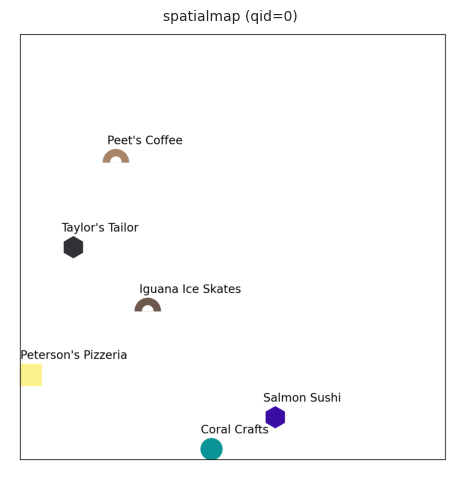

ID: spatialmap.vqa.2011.0
Task: spatialmap | Question type: qid=0
Ground Truth: Northeast (Option C)
Question: The figure represents a map with multiple objects. Each object is associated with a name as shown in the figure. Please answer the following multiple-choice question based on the provided information. In which direction is Taylor's Tailor relative to Peterson's Pizzeria? Available options:
A. Southeast
B. Northwest
C. Northeast
D. Southwest....

[Molmo2-8B] WRONG
  Predicted: northwest
  Raw answer (first 200 chars): B. Northwest. Taylor's Tailor is located at coordinates (1, 3), while Peterson's Pizzeria is at (0, 4). Moving from Peterson's Pizzeria to Taylor's Tailor involves moving one unit to the left (west) a

[Qwen3-4B] WRONG
  Predicted: northwest
  Raw answer (first 200 chars): Taylor's Tailor is located northwest of Peterson's Pizzeria.

Step 1: Identify the positions of both locations on the map. Peterson's Pizzeria is in the bottom-left corner, marked with a yellow 

In [12]:
# --- SPATIALMAP ERROR: Direction Confusion ---
# Select the case that most top models got wrong
spatialmap_errors = df[(df['task'] == 'spatialmap') & (df['qid'] == 0) & (~df['exact'])]
error_counts = spatialmap_errors.groupby('sample_id').size().sort_values(ascending=False)
hard_map_id = error_counts.index[0]

print("=" * 60)
print("SPATIALMAP: Direction Confusion Example")
print("=" * 60)
show_error_case(hard_map_id)

MAZENAV: Path Counting Error Example


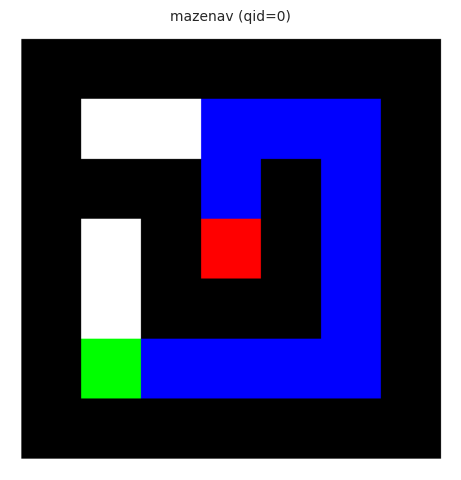

ID: mazenav.vqa.116.0
Task: mazenav | Question type: qid=0
Ground Truth: 0 (Option C)
Question: The figure represents a Maze, where the colored blocks have the following meanings:
- Black blocks represent walls that are impassable barriers.
- White blocks represent navigable paths within the maze, but not necessarily the correct path to the exit.
- Green block denotes the starting point (S) of the maze.
- Red block marks the endpoint or the exit (E) of the maze.
- The objective is to navigat...

[Molmo2-8B] WRONG
  Predicted: 1
  Raw answer (first 200 chars): A. 1

Step-by-step explanation:
1. Identify the starting point (S) at the green block and the endpoint (E) at the red block.
2. Trace the path marked by Blue blocks from S to E.
3. Analyze the movemen

[Qwen3-4B] WRONG
  Predicted: 1
  Raw answer (first 200 chars): A. 1

The blue path starts at the green square (S), moves right to the first white block, then turns down into the blue block, continues down, turns right to go right i

In [13]:
# --- MAZENAV ERROR: Path Counting Difficulty ---
mazenav_errors = df[(df['task'] == 'mazenav') & (df['qid'] == 0) & (~df['exact'])]
error_counts_maze = mazenav_errors.groupby('sample_id').size().sort_values(ascending=False)
hard_maze_id = error_counts_maze.index[0]

print("=" * 60)
print("MAZENAV: Path Counting Error Example")
print("=" * 60)
show_error_case(hard_maze_id)

SPATIALGRID: Animal Identification Error Example


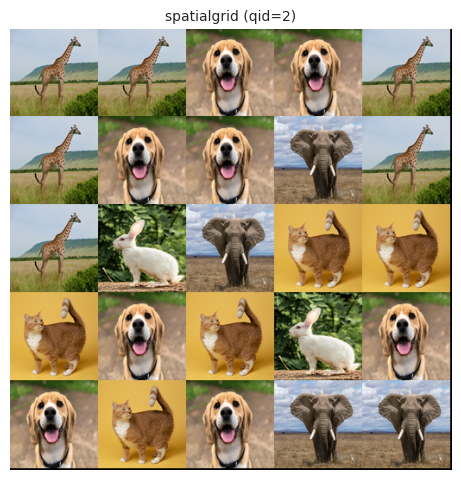

ID: spatialgrid.vqa.396.2
Task: spatialgrid | Question type: qid=2
Ground Truth: giraffe (Option B)
Question: The figure represents a 5x5 grid (5 rows and 5 columns) containing various animals, where each 1x1 square is considered a block and each block contains an animal from ['cat', 'dog', 'elephant', 'giraffe', 'rabbit'].

 Please answer the following question based on the provided information. What is the animal of the block located at the first row, second column of the grid? Available options:
A. ele...

[Molmo2-8B] WRONG
  Predicted: dog
  Raw answer (first 200 chars): C. dog

Step-by-step explanation:
1. The grid is described as 5x5, with the first row being the top row.
2. The question asks about the first row, second column, which is the top middle block.
3. The 

[Qwen3-4B] WRONG
  Predicted: dog
  Raw answer (first 200 chars): The animal in the first row, second column is a dog.

Step-by-step reasoning:
1. The grid is 5x5, meaning there are 5 rows and 5 columns.
2. The "firs

In [14]:
# --- SPATIALGRID ERROR: Animal Misidentification ---
grid_errors = df[(df['task'] == 'spatialgrid') & (df['qid'].isin([1, 2])) & (~df['exact'])]
error_counts_grid = grid_errors.groupby('sample_id').size().sort_values(ascending=False)
hard_grid_id = error_counts_grid.index[0]

print("=" * 60)
print("SPATIALGRID: Animal Identification Error Example")
print("=" * 60)
show_error_case(hard_grid_id)

SPATIALREAL: Real-World Spatial Reasoning Error Example


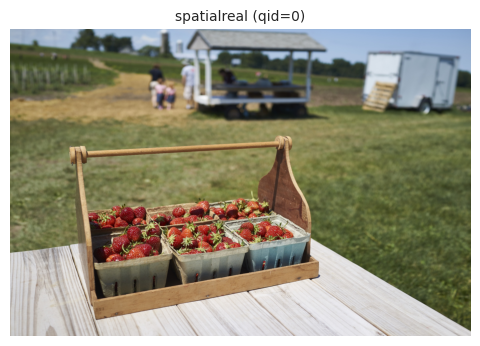

ID: spatialreal.vqa.sa_1543979.0
Task: spatialreal | Question type: qid=0
Ground Truth: six (Option D)
Question: Please answer the following question based on the image. How many individual cartons of strawberries are there in the wooden basket? Available options:
A. eight
B. ten
C. four
D. six
...

[Molmo2-8B] WRONG
  Predicted: 6
  Raw answer (first 200 chars): D. six

Step-by-step explanation:
1. The image description mentions a wooden basket containing multiple cartons of strawberries.
2. It specifically states "six cartons of strawberries."
3. The options

[Qwen3-4B] WRONG
  Predicted: 6
  Raw answer (first 200 chars): There are six individual cartons of strawberries in the wooden basket.  
Step-by-step reasoning:  
1. The image shows a wooden basket with a handle, placed on a white wooden table.  
2. Inside the bas

[MiniCPM-V-4.5] WRONG
  Predicted: 6
  Raw answer (first 200 chars): D. six

The wooden basket contains two rows of cartons, each row having three individual cartons 

In [15]:
# --- SPATIALREAL ERROR: Real-world Counting Failure ---
real_errors = df[(df['task'] == 'spatialreal') & (~df['exact'])]
error_counts_real = real_errors.groupby('sample_id').size().sort_values(ascending=False)
hard_real_id = error_counts_real.index[0]

print("=" * 60)
print("SPATIALREAL: Real-World Spatial Reasoning Error Example")
print("=" * 60)
show_error_case(hard_real_id)

CORRECT EXAMPLES (for comparison)

--- SPATIALMAP (Molmo2-8B correct) ---


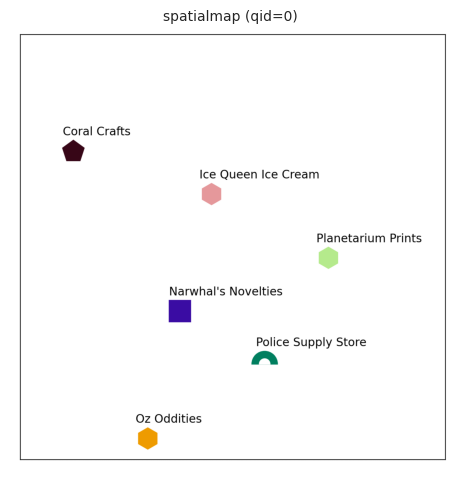

ID: spatialmap.vqa.2000.0
Task: spatialmap | Question type: qid=0
Ground Truth: Northeast (Option A)
Question: The figure represents a map with multiple objects. Each object is associated with a name as shown in the figure. Please answer the following multiple-choice question based on the provided information. In which direction is Planetarium Prints relative to Police Supply Store? Available options:
A. Northeast
B. Northwest
C. Southwest
D. Southeast....

[Molmo2-8B] CORRECT
  Predicted: northeast
  Raw answer (first 200 chars): A. Northeast

Step-by-step explanation:
1. Locate Planetarium Prints on the map.
2. Locate Police Supply Store on the map.
3. Determine the relative position of Planetarium Prints compared to Police S


--- MAZENAV (Molmo2-8B correct) ---


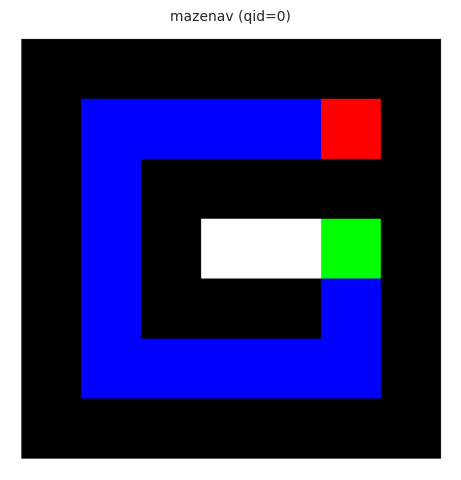

ID: mazenav.vqa.2.0
Task: mazenav | Question type: qid=0
Ground Truth: 3 (Option C)
Question: The figure represents a Maze, where the colored blocks have the following meanings:
- Black blocks represent walls that are impassable barriers.
- White blocks represent navigable paths within the maze, but not necessarily the correct path to the exit.
- Green block denotes the starting point (S) of the maze.
- Red block marks the endpoint or the exit (E) of the maze.
- The objective is to navigat...

[Molmo2-8B] CORRECT
  Predicted: 3
  Raw answer (first 200 chars): C. 3

Step-by-step explanation:
1. Start at the green block (S) and follow the blue path.
2. Move right, then down, then right again.
3. Count the first right turn: 1
4. Continue down, then left, then




--- SPATIALGRID (Molmo2-8B correct) ---


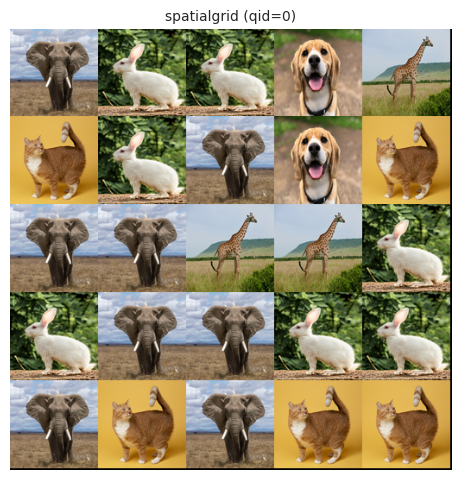

ID: spatialgrid.vqa.0.0
Task: spatialgrid | Question type: qid=0
Ground Truth: 2 (Option C)
Question: The figure represents a 5x5 grid (5 rows and 5 columns) containing various animals, where each 1x1 square is considered a block and each block contains an animal from ['cat', 'dog', 'elephant', 'giraffe', 'rabbit'].

 Please answer the following question based on the provided information. How many blocks contain dog? Available options:
A. 5
B. 6
C. 2
D. 7....

[Molmo2-8B] CORRECT
  Predicted: 2
  Raw answer (first 200 chars): C. 2

Step-by-step explanation:
1. The grid is 5x5, so there are 25 blocks in total.
2. The animals are distributed across the grid, with each animal appearing multiple times.
3. To find the number of


--- SPATIALREAL (Molmo2-8B correct) ---


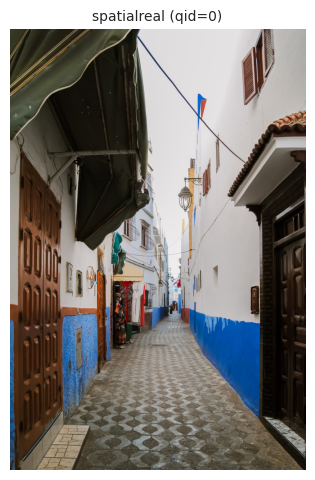

ID: spatialreal.vqa.sa_1544044.0
Task: spatialreal | Question type: qid=0
Ground Truth: 2 (Option B)
Question: Please answer the following question based on the image. How many different door bells are described in the image? Available options:
A. 3
B. 2
C. 4
D. 1
...

[Molmo2-8B] CORRECT
  Predicted: 2
  Raw answer (first 200 chars): B. 2

Step-by-step explanation:
1. The description mentions "two different door bells" in the image.
2. It specifies that one door bell is "brown" and the other is "white".
3. These two distinct door 



In [16]:
# Show one correct example per task for comparison
print("=" * 60)
print("CORRECT EXAMPLES (for comparison)")
print("=" * 60)

for task in ['spatialmap', 'mazenav', 'spatialgrid', 'spatialreal']:
    correct = df[(df['task'] == task) & (df['exact']) & (df['model'] == 'Molmo2-8B')]
    if len(correct) > 0:
        sid = correct.iloc[0]['sample_id']
        print(f'\n--- {task.upper()} (Molmo2-8B correct) ---')
        show_error_case(sid, model_name='Molmo2-8B')

## 5. Per-Instance Difficulty

**Purpose**: Not all questions are equally hard. This section measures difficulty as the fraction of models that answer a question incorrectly, revealing the distribution of question difficulty across the benchmark.

- **Figure 5a** is a histogram of difficulty scores. A bimodal distribution (many easy + many hard questions) would indicate that the benchmark has clear discriminative range.
- **Table 5b** lists the hardest instances (all 11 models wrong) and easiest instances (all 11 models correct).
- **Figure 5c** shows difficulty box plots per question type, revealing which question types are universally hard.
- **Figure 5d** explores whether difficulty correlates with the oracle answer value (e.g., are larger counts harder to identify?).

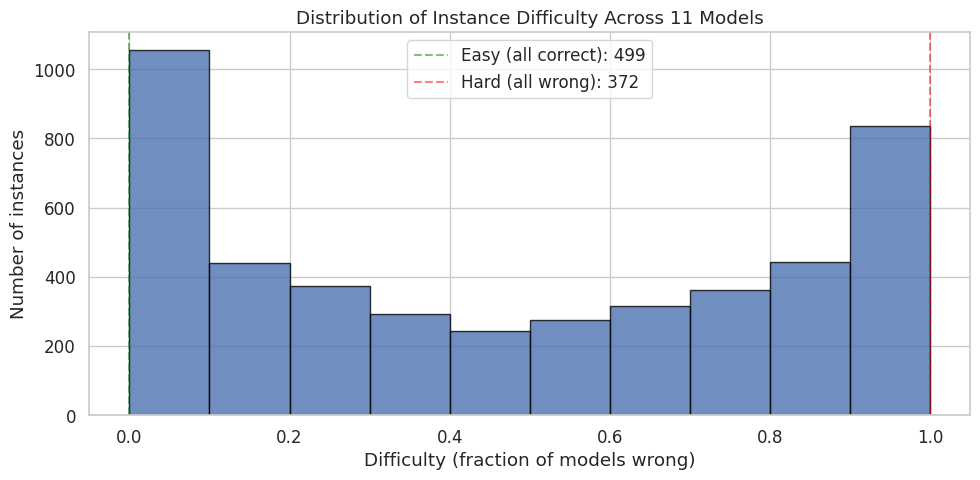

Total unique instances: 4635
Easy (all 11 models correct): 499 (10.8%)
Hard (all 11 models wrong): 372 (8.0%)


In [17]:
# 5a: Difficulty histogram
difficulty = df.groupby('sample_id').agg(
    wrong=('exact', lambda x: 1 - x.mean()),
    task=('task', 'first'),
    qid=('qid', 'first'),
    oracle=('oracle', 'first'),
    task_qid=('task_qid', 'first'),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(difficulty['wrong'], bins=np.arange(0, 1.05, 0.1), edgecolor='black', alpha=0.8)
ax.set_xlabel('Difficulty (fraction of models wrong)')
ax.set_ylabel('Number of instances')
ax.set_title('Distribution of Instance Difficulty Across 11 Models')
n_easy = (difficulty['wrong'] == 0).sum()
n_hard = (difficulty['wrong'] == 1).sum()
ax.axvline(x=0, color='green', linestyle='--', alpha=0.5, label=f'Easy (all correct): {n_easy}')
ax.axvline(x=1, color='red', linestyle='--', alpha=0.5, label=f'Hard (all wrong): {n_hard}')
ax.legend()
plt.tight_layout()
plt.savefig('analysis_figures/06_difficulty_hist.png', dpi=150)
plt.show()
print(f'Total unique instances: {len(difficulty)}')
print(f'Easy (all 11 models correct): {n_easy} ({n_easy/len(difficulty)*100:.1f}%)')
print(f'Hard (all 11 models wrong): {n_hard} ({n_hard/len(difficulty)*100:.1f}%)')

In [18]:
# 5b: Top hardest and easiest instances
print('=== HARDEST INSTANCES (all 11 models wrong) ===')
hardest = difficulty[difficulty['wrong'] == 1].head(10)
for _, row in hardest.iterrows():
    print(f'  {row["sample_id"]:<30} | {row["task"]:<14} qid={row["qid"]} | oracle="{row["oracle"]}"')

print(f'\n=== EASIEST INSTANCES (all 11 models correct) ===')
easiest = difficulty[difficulty['wrong'] == 0].head(10)
for _, row in easiest.iterrows():
    print(f'  {row["sample_id"]:<30} | {row["task"]:<14} qid={row["qid"]} | oracle="{row["oracle"]}"')

=== HARDEST INSTANCES (all 11 models wrong) ===
  mazenav.vqa.0.1                | mazenav        qid=1 | oracle="2"
  mazenav.vqa.102.1              | mazenav        qid=1 | oracle="0"
  mazenav.vqa.103.0              | mazenav        qid=0 | oracle="0"
  mazenav.vqa.103.1              | mazenav        qid=1 | oracle="0"
  mazenav.vqa.104.2              | mazenav        qid=2 | oracle="yes"
  mazenav.vqa.106.1              | mazenav        qid=1 | oracle="1"
  mazenav.vqa.111.1              | mazenav        qid=1 | oracle="0"
  mazenav.vqa.114.0              | mazenav        qid=0 | oracle="0"
  mazenav.vqa.114.1              | mazenav        qid=1 | oracle="2"
  mazenav.vqa.116.0              | mazenav        qid=0 | oracle="0"

=== EASIEST INSTANCES (all 11 models correct) ===
  mazenav.vqa.0.2                | mazenav        qid=2 | oracle="no"
  mazenav.vqa.143.2              | mazenav        qid=2 | oracle="no"
  mazenav.vqa.299.2              | mazenav        qid=2 | oracle="no"

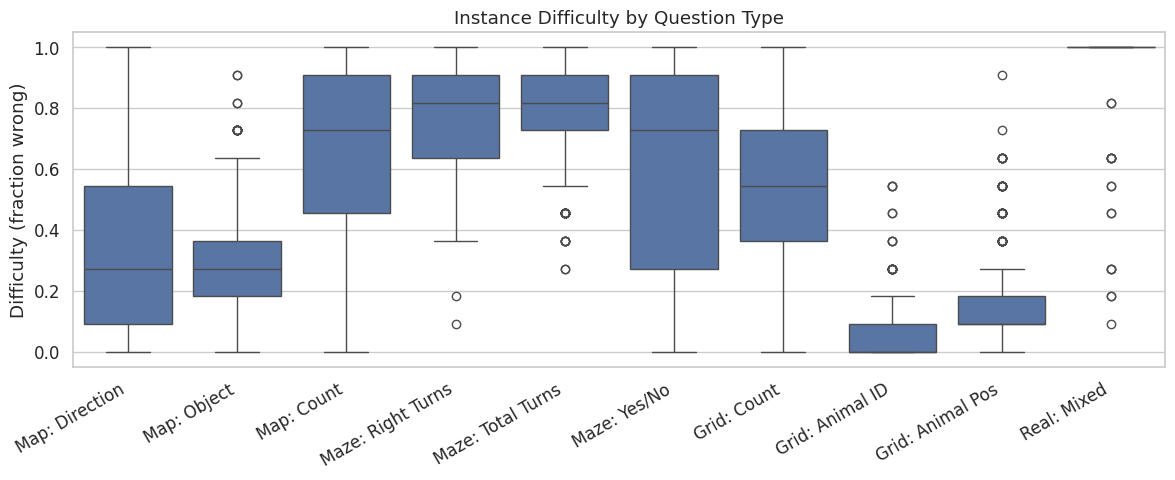

In [19]:
# 5c: Difficulty by task/qid box plot
fig, ax = plt.subplots(figsize=(12, 5))
order = [TASK_QID_LABELS.get((t, q), '') for t in ['spatialmap','mazenav','spatialgrid','spatialreal'] for q in range(3)]
order = [o for o in order if o in difficulty['task_qid'].values]
sns.boxplot(data=difficulty, x='task_qid', y='wrong', order=order, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Difficulty (fraction wrong)')
ax.set_title('Instance Difficulty by Question Type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('analysis_figures/07_difficulty_boxplot.png', dpi=150)
plt.show()

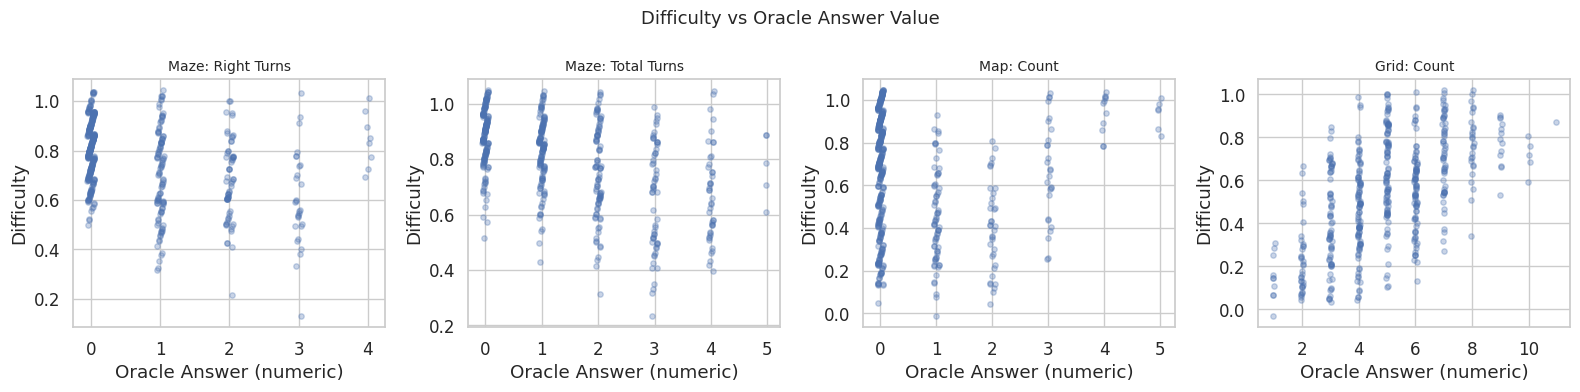

In [20]:
# 5d: Difficulty vs oracle answer for numeric tasks
numeric_tasks = [('mazenav', 0), ('mazenav', 1), ('spatialmap', 2), ('spatialgrid', 0)]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (task, qid) in zip(axes, numeric_tasks):
    tdf = difficulty[(difficulty['task'] == task) & (difficulty['qid'] == qid)].copy()
    tdf['oracle_num'] = pd.to_numeric(tdf['oracle'], errors='coerce')
    tdf = tdf.dropna(subset=['oracle_num'])
    if len(tdf) == 0:
        continue
    jitter = np.random.uniform(-0.05, 0.05, len(tdf))
    ax.scatter(tdf['oracle_num'] + jitter, tdf['wrong'] + jitter, alpha=0.3, s=15)
    ax.set_xlabel('Oracle Answer (numeric)')
    ax.set_ylabel('Difficulty')
    label = TASK_QID_LABELS.get((task, qid), f'{task}:q{qid}')
    ax.set_title(label, fontsize=10)

plt.suptitle('Difficulty vs Oracle Answer Value', fontsize=13)
plt.tight_layout()
plt.savefig('analysis_figures/08_difficulty_vs_oracle.png', dpi=150)
plt.show()

## 6. Model Correlation

**Purpose**: Do models tend to get the same questions right/wrong, or do they have complementary strengths? Understanding model correlation helps identify whether different architectures have genuinely different reasoning abilities or simply reproduce the same error patterns.

- **Figure 6a** shows pairwise Pearson correlation of correctness vectors. High correlation means models agree on which questions they get right/wrong. Low correlation suggests complementary capabilities.
- **Figure 6b** shows raw agreement rate (fraction of samples where two models produce the same correct/wrong result). This captures overall behavioral similarity.

**What to look for**: Models from the same family (e.g., Molmo2-4B and Molmo2-8B) should correlate highly. Cross-family correlations reveal whether spatial reasoning ability is architecture-dependent.

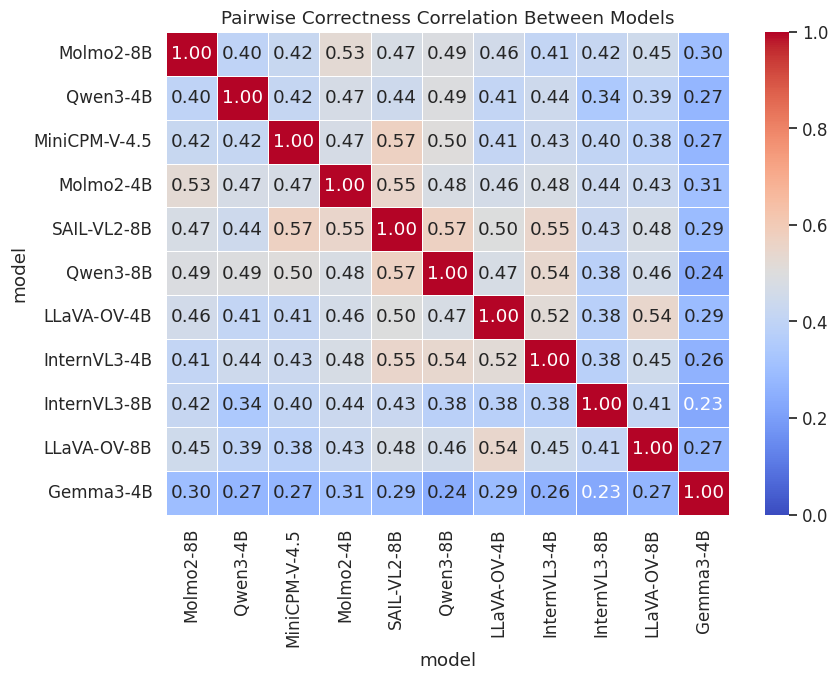

In [21]:
# 6a: Pairwise correctness correlation
correct_matrix = df.pivot_table(index='sample_id', columns='model', values='exact')
correct_matrix = correct_matrix.reindex(columns=MODEL_ORDER)
corr = correct_matrix.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=0, vmax=1,
            ax=ax, linewidths=0.5)
ax.set_title('Pairwise Correctness Correlation Between Models')
plt.tight_layout()
plt.savefig('analysis_figures/09_model_correlation.png', dpi=150)
plt.show()

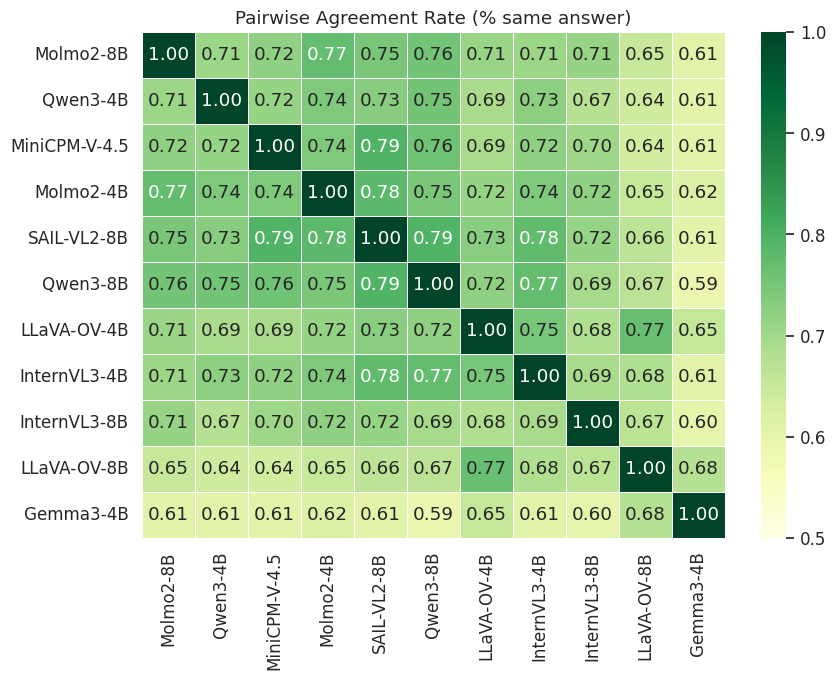

In [22]:
# 6b: Agreement rate heatmap
models = MODEL_ORDER
agree = pd.DataFrame(index=models, columns=models, dtype=float)
for m1 in models:
    for m2 in models:
        a = correct_matrix[m1]
        b = correct_matrix[m2]
        agree.loc[m1, m2] = (a == b).mean()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(agree.astype(float), annot=True, fmt='.2f', cmap='YlGn',
            vmin=0.5, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Pairwise Agreement Rate (% same answer)')
plt.tight_layout()
plt.savefig('analysis_figures/10_agreement_heatmap.png', dpi=150)
plt.show()

## 7. Confusion Analysis

**Purpose**: When models make mistakes, what do they predict instead of the correct answer? Confusion matrices reveal systematic error patterns.

- **Figure 7a** shows direction confusion matrices for spatialmap qid0 (NE/NW/SE/SW). Off-diagonal entries indicate which directions get confused. A common pattern is confusing NE with SE (same east component) or NE with NW (same north component).
- **Figure 7b** shows animal confusion matrices for spatialgrid qid1+2. Since there are only 5 animals (cat, dog, elephant, giraffe, rabbit), we can see exactly which animals are most often misidentified.
- **Figure 7c** aggregates confusion across all models to show universal confusion patterns.

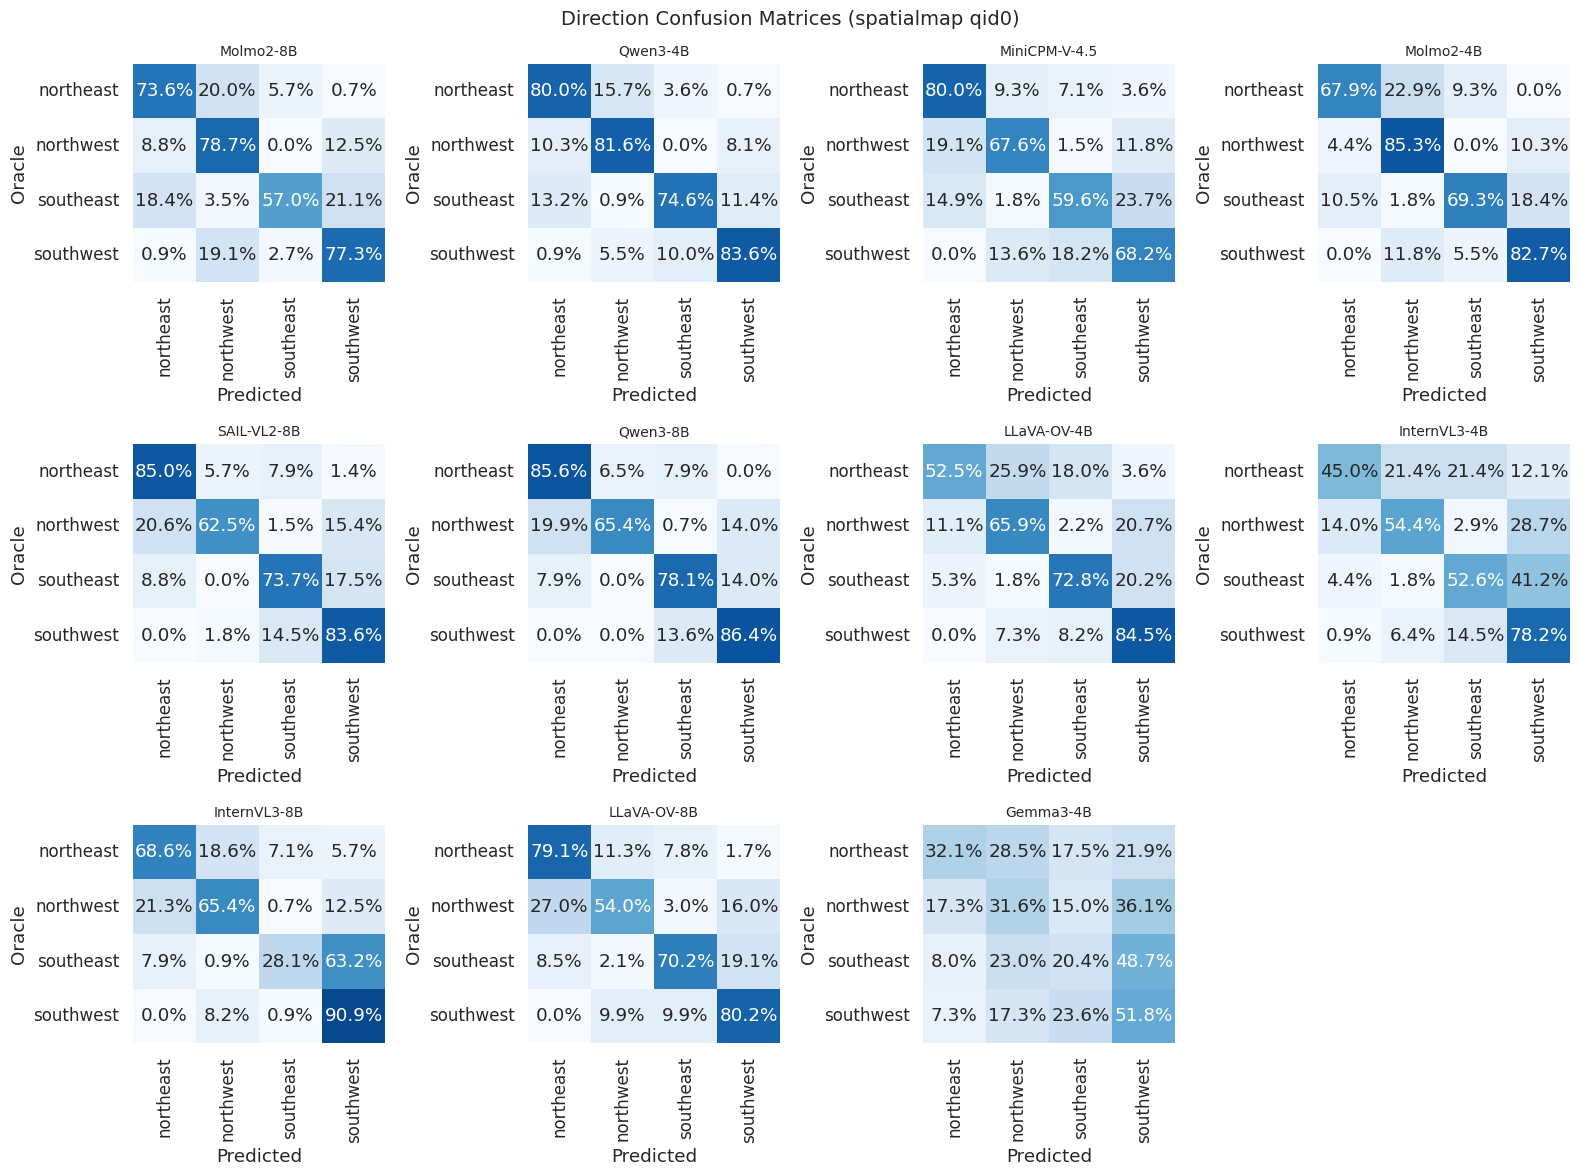

In [23]:
# 7a: Direction confusion matrices (spatialmap qid0)
dir_df = df[(df['task'] == 'spatialmap') & (df['qid'] == 0)].copy()
directions = ['northeast', 'northwest', 'southeast', 'southwest']

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for idx, model in enumerate(MODEL_ORDER):
    ax = axes.flat[idx]
    mdf = dir_df[dir_df['model'] == model]
    cm = pd.DataFrame(0, index=directions, columns=directions)
    for _, row in mdf.iterrows():
        oracle_d = row['oracle']
        pred_d = row['extracted']
        if oracle_d in directions and pred_d in directions:
            cm.loc[oracle_d, pred_d] += 1
    cm_norm = cm.div(cm.sum(axis=1), axis=0).fillna(0)
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues', ax=ax,
                vmin=0, vmax=1, cbar=False)
    ax.set_title(model, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Oracle')

if len(MODEL_ORDER) < 12:
    axes.flat[-1].set_visible(False)

plt.suptitle('Direction Confusion Matrices (spatialmap qid0)', fontsize=14)
plt.tight_layout()
plt.savefig('analysis_figures/11_direction_confusion.png', dpi=150)
plt.show()

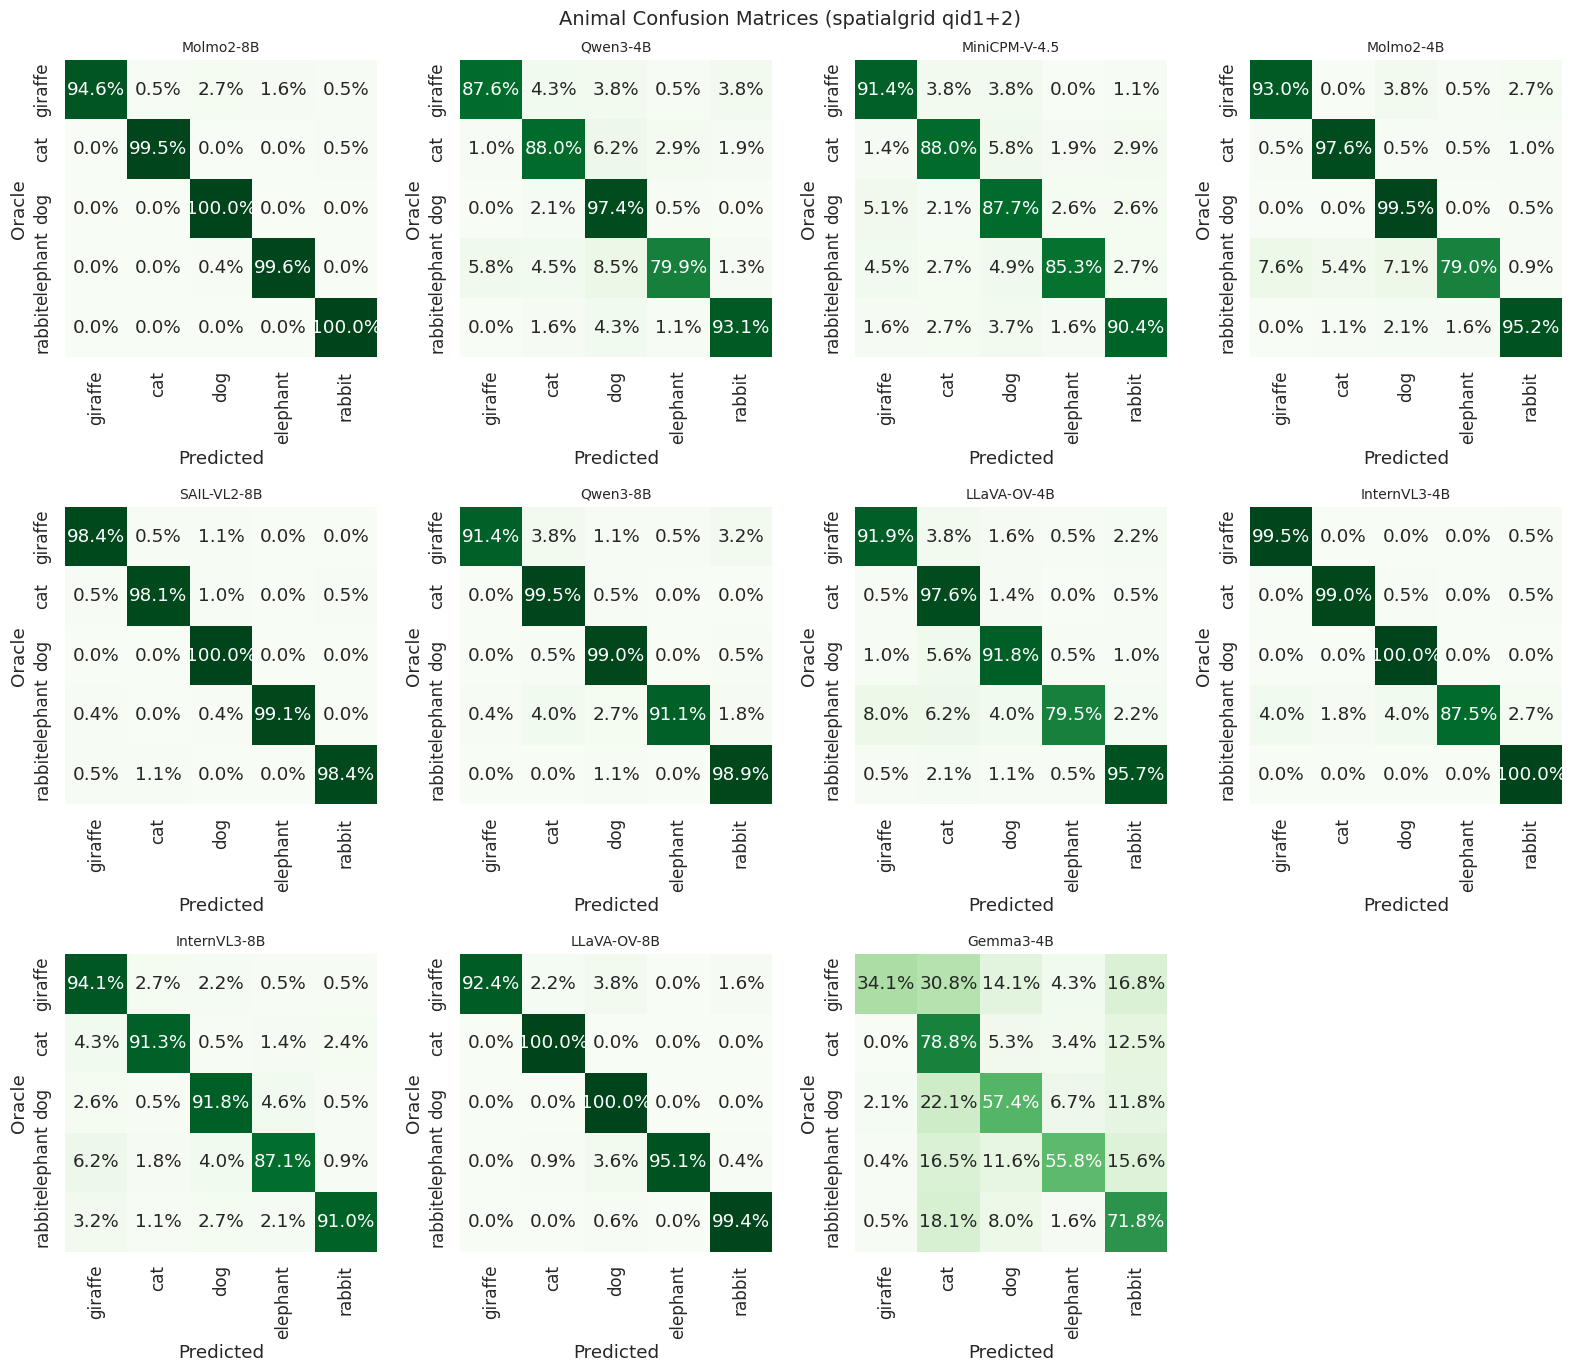

In [24]:
# 7b: Animal confusion matrices (spatialgrid qid1+2)
animal_df = df[(df['task'] == 'spatialgrid') & (df['qid'].isin([1, 2]))].copy()
animals = ['giraffe', 'cat', 'dog', 'elephant', 'rabbit']

fig, axes = plt.subplots(3, 4, figsize=(16, 14))
for idx, model in enumerate(MODEL_ORDER):
    ax = axes.flat[idx]
    mdf = animal_df[animal_df['model'] == model]
    cm = pd.DataFrame(0, index=animals, columns=animals)
    for _, row in mdf.iterrows():
        oracle_a = row['oracle']
        pred_a = row['extracted']
        if oracle_a in animals and pred_a in animals:
            cm.loc[oracle_a, pred_a] += 1
    cm_norm = cm.div(cm.sum(axis=1), axis=0).fillna(0)
    sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Greens', ax=ax,
                vmin=0, vmax=1, cbar=False)
    ax.set_title(model, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Oracle')

if len(MODEL_ORDER) < 12:
    axes.flat[-1].set_visible(False)

plt.suptitle('Animal Confusion Matrices (spatialgrid qid1+2)', fontsize=14)
plt.tight_layout()
plt.savefig('analysis_figures/12_animal_confusion.png', dpi=150)
plt.show()

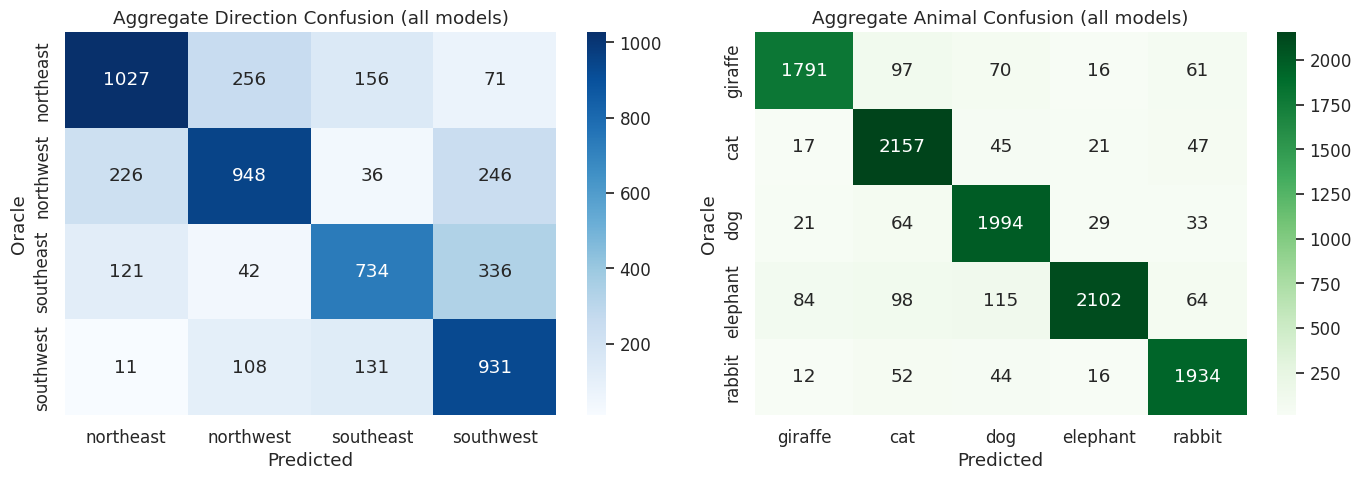

In [25]:
# 7c: Aggregate confusion patterns
cm_all_dir = pd.DataFrame(0, index=directions, columns=directions)
for _, row in dir_df.iterrows():
    oracle_d, pred_d = row['oracle'], row['extracted']
    if oracle_d in directions and pred_d in directions:
        cm_all_dir.loc[oracle_d, pred_d] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_all_dir, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Aggregate Direction Confusion (all models)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Oracle')

cm_all_animal = pd.DataFrame(0, index=animals, columns=animals)
for _, row in animal_df.iterrows():
    oracle_a, pred_a = row['oracle'], row['extracted']
    if oracle_a in animals and pred_a in animals:
        cm_all_animal.loc[oracle_a, pred_a] += 1

sns.heatmap(cm_all_animal, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Aggregate Animal Confusion (all models)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Oracle')

plt.tight_layout()
plt.savefig('analysis_figures/13_aggregate_confusion.png', dpi=150)
plt.show()

## 8. Answer Format Analysis

**Purpose**: Models differ in how they format their responses (e.g., "A. Northeast" vs "The answer is A" vs free-form text). This section analyzes:
1. Which format each model tends to use
2. Whether format choice correlates with accuracy

Understanding format preferences helps diagnose whether extraction errors are due to the model producing unexpected output formats, and whether certain formats lead to more reliable evaluation.

In [26]:
# Format classification
def classify_format(raw):
    if not raw or not raw.strip():
        return 'empty'
    raw = raw.strip()
    if re.match(r'^[A-D][\.\:]\s', raw):
        return 'option_dot'
    if re.match(r'^[A-D]$', raw):
        return 'bare_letter'
    if re.search(r'(?i)the answer is [A-D]', raw):
        return 'answer_is_X'
    if re.search(r'\*\*Concise Answer:\*\*', raw):
        return 'markdown_concise'
    if re.search(r'\*\*Answer:\*\*', raw):
        return 'markdown_answer'
    return 'free_text'

df['format'] = df['raw'].apply(classify_format)
format_counts = df.groupby(['model', 'format']).size().unstack(fill_value=0)
format_pct = format_counts.div(format_counts.sum(axis=1), axis=0) * 100
format_pct = format_pct.reindex(MODEL_ORDER)

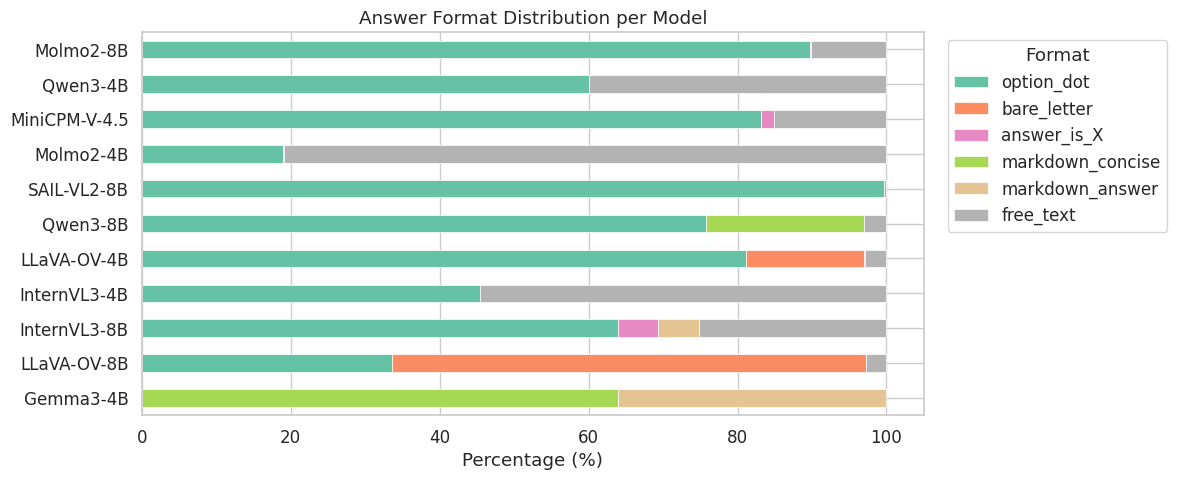

In [27]:
# 8a: Stacked bar chart of format distribution
fig, ax = plt.subplots(figsize=(12, 5))
format_cols = ['option_dot', 'bare_letter', 'answer_is_X', 'markdown_concise', 'markdown_answer', 'free_text', 'empty']
cols_present = [c for c in format_cols if c in format_pct.columns]
format_pct[cols_present].plot(kind='barh', stacked=True, ax=ax,
    colormap='Set2', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Percentage (%)')
ax.set_ylabel('')
ax.set_title('Answer Format Distribution per Model')
ax.legend(title='Format', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('analysis_figures/14_format_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# 8b: Accuracy by format type
format_acc = df.groupby(['model', 'format'])['exact'].mean().unstack()
format_acc = format_acc.reindex(MODEL_ORDER) * 100
cols_present = [c for c in format_cols if c in format_acc.columns]
format_acc[cols_present].style.format('{:.1f}').highlight_max(axis=1, color='lightgreen')

format,option_dot,bare_letter,answer_is_X,markdown_concise,markdown_answer,free_text
model,,,,,,
Molmo2-8B,65.4,nan,83.3,nan,nan,22.1
Qwen3-4B,50.6,nan,nan,nan,nan,69.6
MiniCPM-V-4.5,52.6,nan,87.8,nan,nan,86.6
Molmo2-4B,55.2,nan,28.6,nan,nan,59.8
SAIL-VL2-8B,61.0,nan,nan,nan,nan,7.7
Qwen3-8B,64.2,nan,nan,36.5,nan,79.7
LLaVA-OV-4B,53.6,0.0,0.0,nan,nan,33.3
InternVL3-4B,49.7,nan,nan,nan,nan,58.4
InternVL3-8B,41.5,nan,58.5,nan,60.1,82.4
